# LightGlue Demo
In this notebook we match two pairs of images using LightGlue with early stopping and point pruning.

In [1]:
# If we are on colab: this clones the repo and installs the dependencies
from pathlib import Path

from LightGlue.lightglue import LightGlue, SuperPoint, DISK
from LightGlue.lightglue.utils import load_image, rbd
from LightGlue.lightglue import viz2d
import torch

torch.set_grad_enabled(False)
rho_gray_path = r"output/visual_test/rho_gray"

## Load extractor and matcher module
In this example we use SuperPoint features combined with LightGlue.

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # 'mps', 'cpu'

extractor = SuperPoint(max_num_keypoints=2048).eval().to(device)  # load the extractor
matcher = LightGlue(features="superpoint").eval().to(device)

## Easy example
The top image shows the matches, while the bottom image shows the point pruning across layers. In this case, LightGlue prunes a few points with occlusions, but is able to stop the context aggregation after 4/9 layers.

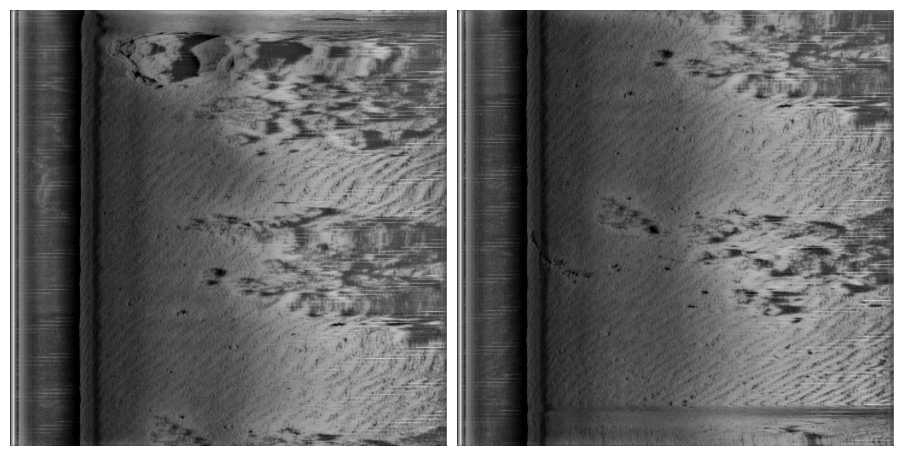

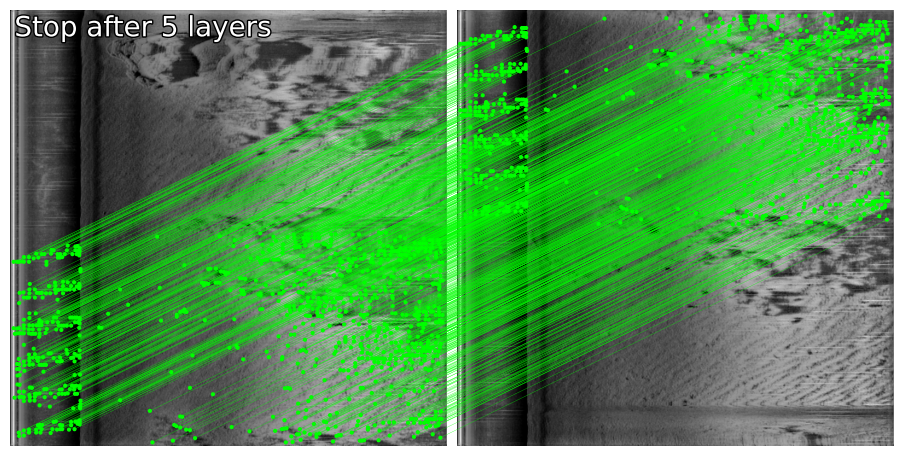

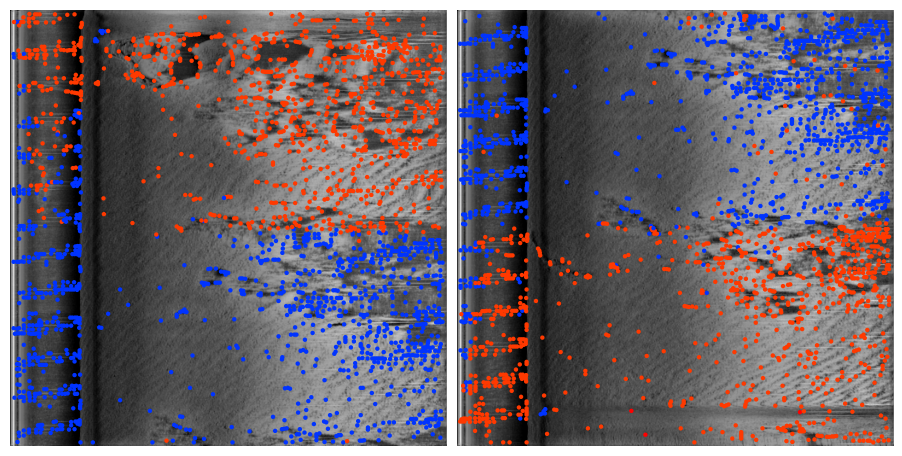

In [3]:
import os
from tqdm import tqdm

file_list: list[str] = sorted(os.listdir(rho_gray_path))

# First two images for testing
image0 = load_image(Path(Path(rho_gray_path) / file_list[0]))
image1 = load_image(Path(Path(rho_gray_path) / file_list[1]))

feats0 = extractor.extract(image0.to(device))
feats1 = extractor.extract(image1.to(device))

matches01 = matcher({"image0": feats0, "image1": feats1})
feats0, feats1, matches01 = [
    # remove batch dimension
    rbd(x) for x in [feats0, feats1, matches01]
]  

kpts0, kpts1, matches = feats0["keypoints"], feats1["keypoints"], matches01["matches"]# matches01["matches"] are pairs of indices of keypoints that match
m_kpts0, m_kpts1 = kpts0[matches[..., 0]], kpts1[matches[..., 1]] # matched keypoints in each image

axes = viz2d.plot_images([image0, image1])

axes = viz2d.plot_images([image0, image1])
viz2d.plot_matches(m_kpts0, m_kpts1, color="lime", lw=0.2)
viz2d.add_text(0, f'Stop after {matches01["stop"]} layers', fs=20)

kpc0, kpc1 = viz2d.cm_prune(matches01["prune0"]), viz2d.cm_prune(matches01["prune1"]) # Keypoint colors based on pruning scores
viz2d.plot_images([image0, image1])
viz2d.plot_keypoints([kpts0, kpts1], colors=[kpc0, kpc1], ps=10)

### Matches for all the images

In [4]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import numpy as np 

def extract_matches(image0: torch.Tensor, image1: torch.Tensor, extractor: SuperPoint, matcher: LightGlue):

    # Extract features from both images
    feats0 = extractor.extract(image0.to(device))
    feats1 = extractor.extract(image1.to(device))
    
    # Obtain matches
    matches01 = matcher({"image0": feats0, "image1": feats1})
    feats0, feats1, matches01 = [
        # remove batch dimension
        rbd(x) for x in [feats0, feats1, matches01]
    ]  
    
    # Extract keypoints and matches
    kpts0, kpts1, matches = feats0["keypoints"], feats1["keypoints"], matches01["matches"] # Indices of matched keypoints in both images
    m_kpts0, m_kpts1 = kpts0[matches[..., 0]], kpts1[matches[..., 1]] 

    return m_kpts0, m_kpts1

def plot_images(imgs, titles=None, cmaps="gray", dpi=100, pad=0.5, adaptive=True):
    """Create a figure with images, but do not show it.
    
    Args:
        imgs: list of NumPy RGB (H, W, 3) or PyTorch RGB (3, H, W) or mono (H, W).
        titles: list of strings.
        cmaps: colormap(s) for monochrome images.
        adaptive: whether the figure size should fit the image aspect ratios.
    
    Returns:
        fig, axes
    """
    imgs = [
        (
            img.permute(1, 2, 0).cpu().numpy()
            if (isinstance(img, torch.Tensor) and img.dim() == 3)
            else img
        )
        for img in imgs
    ]

    n = len(imgs)
    if not isinstance(cmaps, (list, tuple)):
        cmaps = [cmaps] * n

    if adaptive:
        ratios = [img.shape[1] / img.shape[0] for img in imgs]
    else:
        ratios = [4 / 3] * n

    figsize = [sum(ratios) * 4.5, 4.5]
    fig, axes = plt.subplots(
        1, n, figsize=figsize, dpi=dpi, gridspec_kw={"width_ratios": ratios}
    )

    if n == 1:
        axes = [axes]

    for i in range(n):
        axes[i].imshow(imgs[i], cmap=plt.get_cmap(cmaps[i]))
        axes[i].set_xticks([])
        axes[i].set_yticks([])
        axes[i].set_axis_off()
        for spine in axes[i].spines.values():
            spine.set_visible(False)
        if titles:
            axes[i].set_title(titles[i])

    fig.tight_layout(pad=pad)
    return fig, axes


def plot_keypoints(kpts, colors="lime", ps=4, axes=None, a=1.0):
    """Plot keypoints on existing axes.
    
    Args:
        kpts: list of ndarrays of size (N, 2).
        colors: string, or list of colors for each keypoint set.
        ps: point size.
        axes: list of matplotlib axes.
        a: alpha or list of alphas.
    """
    if axes is None:
        raise ValueError("axes must be provided")

    if not isinstance(colors, list):
        colors = [colors] * len(kpts)
    if not isinstance(a, list):
        a = [a] * len(kpts)

    for ax, k, c, alpha in zip(axes, kpts, colors, a):
        if isinstance(k, torch.Tensor):
            k = k.cpu().numpy()
        ax.scatter(k[:, 0], k[:, 1], c=c, s=ps, linewidths=0, alpha=alpha)


def plot_matches(kpts0, kpts1, color=None, lw=1.5, ps=4, a=1.0, labels=None, axes=None, fig=None):
    """Plot matches between two existing image axes.
    
    Args:
        kpts0, kpts1: corresponding keypoints of size (N, 2).
        color: color of each match, string or RGB tuple. Random if None.
        lw: line width.
        ps: endpoint size.
        a: alpha.
        labels: optional labels per match.
        axes: [ax0, ax1]
        fig: matplotlib figure
    """
    if axes is None or len(axes) != 2:
        raise ValueError("axes must be provided as [ax0, ax1]")
    if fig is None:
        raise ValueError("fig must be provided")

    ax0, ax1 = axes

    if isinstance(kpts0, torch.Tensor):
        kpts0 = kpts0.cpu().numpy()
    if isinstance(kpts1, torch.Tensor):
        kpts1 = kpts1.cpu().numpy()

    assert len(kpts0) == len(kpts1)

    if color is None:
        # Replace this with your own cm_grad2d if you already have it
        kpts_norm = (kpts0 - kpts0.min(axis=0, keepdims=True)) / np.ptp(
            kpts0, axis=0, keepdims=True
        )
        color = kpts_norm  # simple fallback
    elif len(color) > 0 and not isinstance(color[0], (tuple, list, np.ndarray)):
        color = [color] * len(kpts0)

    if lw > 0:
        for i in range(len(kpts0)):
            line = matplotlib.patches.ConnectionPatch(
                xyA=(kpts0[i, 0], kpts0[i, 1]),
                xyB=(kpts1[i, 0], kpts1[i, 1]),
                coordsA=ax0.transData,
                coordsB=ax1.transData,
                axesA=ax0,
                axesB=ax1,
                zorder=1,
                color=color[i],
                linewidth=lw,
                clip_on=True,
                alpha=a,
                label=None if labels is None else labels[i],
                picker=5.0,
            )
            line.set_annotation_clip(True)
            fig.add_artist(line)

    ax0.autoscale(enable=False)
    ax1.autoscale(enable=False)

    if ps > 0:
        ax0.scatter(kpts0[:, 0], kpts0[:, 1], c=color, s=ps)
        ax1.scatter(kpts1[:, 0], kpts1[:, 1], c=color, s=ps)


def add_text(
    idx,
    text,
    axes=None,
    pos=(0.01, 0.99),
    fs=15,
    color="w",
    lcolor="k",
    lwidth=2,
    ha="left",
    va="top",
):
    """Add text to one axis."""
    if axes is None:
        raise ValueError("axes must be provided")

    ax = axes[idx]
    t = ax.text(
        *pos, text, fontsize=fs, ha=ha, va=va, color=color, transform=ax.transAxes
    )
    if lcolor is not None:
        t.set_path_effects(
            [
                path_effects.Stroke(linewidth=lwidth, foreground=lcolor),
                path_effects.Normal(),
            ]
        )


def figure_to_image(fig, close=True):
    """Convert a matplotlib figure to a NumPy RGB image."""
    fig.canvas.draw()
    w, h = fig.canvas.get_width_height()
    img = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
    img = img.reshape(h, w, 4)[..., :3].copy()  # RGB
    if close:
        plt.close(fig)
    return img

def save_figure(fig, save_path, close=True, **savefig_kwargs):
    """Save a matplotlib figure to disk without showing it."""
    fig.savefig(save_path, bbox_inches="tight", pad_inches=0, **savefig_kwargs)
    if close: plt.close(fig)

def prepare_mask(mask: torch.Tensor, device):
    '''Convert the mask from int to bool'''
    mask = mask.to(device)

    if mask.dim() == 3:
        # if RGB, take one channel
        mask = mask[0]

    # binary: 1 invalid, 0 valid
    mask = (mask > 0.5).to(torch.uint8)
    return mask


def filter_matches_with_masks(kpts0, kpts1, mask0, mask1):
    # Gets the device
    device = kpts0.device

    # Threshold the masks from int to bool
    mask0 = prepare_mask(mask0, device)
    mask1 = prepare_mask(mask1, device)

    # Gets the mask dimensions
    H0, W0 = mask0.shape
    H1, W1 = mask1.shape

    # Extract the keypoints coordinates
    x0i = torch.round(kpts0[:, 0]).long()
    y0i = torch.round(kpts0[:, 1]).long()
    x1i = torch.round(kpts1[:, 0]).long()
    y1i = torch.round(kpts1[:, 1]).long()

    inside0 = (x0i >= 0) & (x0i < W0) & (y0i >= 0) & (y0i < H0)
    inside1 = (x1i >= 0) & (x1i < W1) & (y1i >= 0) & (y1i < H1)

    valid0 = torch.zeros_like(inside0, dtype=torch.bool)
    valid1 = torch.zeros_like(inside1, dtype=torch.bool)

    valid0[inside0] = (mask0[y0i[inside0], x0i[inside0]] == 0)
    valid1[inside1] = (mask1[y1i[inside1], x1i[inside1]] == 0)

    keep = valid0 & valid1
    return kpts0[keep], kpts1[keep]

In [ ]:
# Matching parameters
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # 'mps', 'cpu'

extractor = SuperPoint(max_num_keypoints=2048).eval().to(device)  # load the extractor
matcher = LightGlue(features="superpoint").eval().to(device)      # load the matcher

# All the images in the file as a list of strings
rho_gray_path = r"output/visual_test/rho_gray"
shadow_mask = r"output/shadow"           # shadow mask images path
z_mask = r"output/visual_test/z_mask"    # elevation mask images path
output_matches_path = r"output/matches"  # output matches path before RANSAC
output_matches_path_final = r"output/matches/final"  # output matches path before RANSAC

# list of files in the directories
file_list: list[str] = sorted(os.listdir(rho_gray_path))
shadow_mask_list: list[str] = sorted(os.listdir(shadow_mask))
z_mask_list: list[str] = sorted(os.listdir(z_mask))

# Matches dictionary 
matches_dict = {
    # "0_1": m_kpts0,
    # "1_2": m_kpts1
}

# Total number of images
N = len(file_list)

for i in range(N-1):        # For every image in the file
    for j in range(i+1, N): # For every other image in the file
        image0 = load_image(Path(Path(rho_gray_path) / file_list[i]))
        image1 = load_image(Path(Path(rho_gray_path) / file_list[j]))

        # Gets matches
        m_kpts0, m_kpts1 = extract_matches(image0, image1, extractor, matcher)

        # Apply shadow map mask
        shadow_i = shadow_mask_list[i]
        shadow_j = shadow_mask_list[j]
        shadow_i_mask = load_image(Path(Path(shadow_mask) / shadow_i))
        shadow_j_mask = load_image(Path(Path(shadow_mask) / shadow_j))
        kpts_shadow0, kpts_shadow1 = filter_matches_with_masks(m_kpts0, m_kpts1, shadow_i_mask, shadow_j_mask)

        # Apply terrain map mask
        z_mask_i = z_mask_list[i]
        z_mask_j = z_mask_list[j]
        z_i_mask = load_image(Path(Path(z_mask) / z_mask_i))
        z_j_mask = load_image(Path(Path(z_mask) / z_mask_j))
        kpts_z0, kpts_z1 = filter_matches_with_masks(kpts_shadow0, kpts_shadow1, z_i_mask, z_j_mask)

        # Save matches before outlier rejection
        # fig, axes = plot_images([image0, image1])
        # plot_matches(m_kpts0, m_kpts1, color="lime", lw=0.2, axes=axes, fig=fig)
        # add_text(0, f'Before {i} and {j}', axes=axes, fs=20)
        # save_figure(fig, output_matches_path + f"/Before {i}_{j}_matches.png")
        
        # Save matches after outlier rejection
        # fig, axes = plot_images([image0, image1])
        # plot_matches(kpts_z0, kpts_z1, color="lime", lw=0.2, axes=axes, fig=fig)
        # add_text(0, f'Matches between {i} and {j}', axes=axes, fs=20)
        # save_figure(fig, output_matches_path_final + f"/{i}_{j}_matches.png")

        # Add matches to the dictionary
        matches_dict[f"{i}_{j}"] = (kpts_z0, kpts_z1)
    
    print(f"Progress: {i}/{N-1}\r")

print(len(list(matches_dict.keys())))


Progress: 0/143
Progress: 1/143
Progress: 2/143
Progress: 3/143
Progress: 4/143
Progress: 5/143
Progress: 6/143
Progress: 7/143
Progress: 8/143
Progress: 9/143
Progress: 10/143
Progress: 11/143
Progress: 12/143
Progress: 13/143
Progress: 14/143
Progress: 15/143
Progress: 16/143
Progress: 17/143
Progress: 18/143
Progress: 19/143
Progress: 20/143
Progress: 21/143
Progress: 22/143
Progress: 23/143
Progress: 24/143
Progress: 25/143
Progress: 26/143
Progress: 27/143
Progress: 28/143
Progress: 29/143
Progress: 30/143
Progress: 31/143
Progress: 32/143
Progress: 33/143
Progress: 34/143
Progress: 35/143
Progress: 36/143
Progress: 37/143
Progress: 38/143
Progress: 39/143
Progress: 40/143
Progress: 41/143
Progress: 42/143
Progress: 43/143
Progress: 44/143
Progress: 45/143
Progress: 46/143
Progress: 47/143
Progress: 48/143
Progress: 49/143
Progress: 50/143
Progress: 51/143
Progress: 52/143
Progress: 53/143
Progress: 54/143
Progress: 55/143
Progress: 56/143
Progress: 57/143
Progress: 58/143
Progres

### RANSAC: Estimate homography removing outliers

In [ ]:
from RANSAC.compute_homography_ransac import compute_homography_ransac
traj_H = []
for i in range(N-1):
    # Calculate homography between i and i+1 images, relative movement
    local_kpts0, local_kpts1 = matches_dict[f"{i}_{i+1}"] # Local matches between i and i+1 images

    # Convert from tensor to numpy array
    H_best, inliers0, inliers1 = compute_homography_ransac(
        local_kpts0.detach().cpu().numpy(),
        local_kpts1.detach().cpu().numpy(),
        model="Projective",
        num_iterations=10_000, # max number of iterations
        t=10              # 10 pixels
    )

    traj_H.append(H_best)

In [ ]:
def to_homogeneous(pt):
    return np.array([pt[0], pt[1], 1.0], dtype=np.float64)

def from_homogeneous(p):
    return p[:2] / p[2]

def trajectory_from_consecutive_homographies(homographies, image_shape):
    if len(image_shape) == 3:
        _, H_img, W_img = image_shape
    else:
        H_img, W_img = image_shape

    center = np.array([W_img / 2.0, H_img / 2.0], dtype=np.float64)
    c_h = to_homogeneous(center)

    traj = [center.copy()]
    H_current_to_ref = np.eye(3, dtype=np.float64)

    for H in homographies:
        H_current_to_ref = H_current_to_ref @ np.linalg.inv(np.asarray(H, dtype=np.float64))
        p_ref = from_homogeneous(H_current_to_ref @ c_h)
        traj.append(p_ref)

    return np.array(traj)

def plot_trajectory(traj, invert_y=True):
    plt.figure(figsize=(8, 8))
    plt.plot(traj[:, 0], traj[:, 1], "-o", linewidth=2, markersize=4)
    plt.scatter(traj[0, 0], traj[0, 1], s=100, marker="s", label="start")
    plt.scatter(traj[-1, 0], traj[-1, 1], s=100, marker="x", label="end")

    dx = np.diff(traj[:, 0])
    dy = np.diff(traj[:, 1])
    plt.quiver(traj[:-1, 0], traj[:-1, 1], dx, dy, angles="xy", scale_units="xy", scale=1)

    plt.axis("equal")
    plt.grid(True)
    plt.xlabel("x [meters]")
    plt.ylabel("y [meters]")
    plt.title("Estimated trajectory from homographies")
    plt.legend()

    if invert_y: plt.gca().invert_yaxis()

    plt.show()

In [ ]:
trajectory = trajectory_from_consecutive_homographies(traj_H[70:140], (200,200))
plot_trajectory(trajectory, invert_y=False)

In [ ]:
import json
json_dict = {k: v.detach().cpu().tolist() if isinstance(v, torch.Tensor) else v
             for k, v in matches_dict.items()}

with open("homographies.json", "w") as f:
    json.dump(json_dict, f, indent=4)